<a href="https://colab.research.google.com/github/Ajay-Sankar-T/Agnirath-Strat/blob/main/Taming_the_Telemetry/Taming_the_Telemetry.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **TELEMETRY ANALYSIS**

---

## **1. Objective**

The goal of this analysis is to estimate key vehicle parameters:

*   **CdA (Drag Area)** → aerodynamic efficiency
*   **Crr (Rolling Resistance Coefficient)** → mechanical losses

using real telemetry data during **coasting conditions**.

---

## **2. Methodology**

---

### 🔹 A. Data Preprocessing

*   Removed invalid data:

    *   ( v \leq 0 )
    *   Missing values

*   Filtered unrealistic conditions:

    *   Gradient constraint: ( |\theta| < 2^\circ ) → near-flat road assumption

---

### 🔹 B. Outlier Handling

*   **Velocity outliers removed using IQR method**
*   **Acceleration outliers removed using statistical filtering (±2σ)**

> This ensures that extreme noise does not distort the regression model.

---

### 🔹 C. Signal Smoothing

*   Applied **rolling mean (window = 10)** to velocity

> Reduces high-frequency noise before differentiation.

---

### 🔹 D. Acceleration Estimation

[ a = \frac{dv}{dt} ]

*   Used numerical differentiation
*   Removed invalid time steps ((dt \leq 0))

---

### 🔹 E. Physical Filtering

*   Considered only:
    [ a < 0 ]

> This isolates **coasting behavior**, where no propulsion force is applied and deceleration is governed by drag and rolling resistance.

---

## **3. Model Formulation**

From physics:

[ a = - (k_1 v^2 + k_2) ]

Where:

*   (k_1) → aerodynamic drag term
*   (k_2) → rolling resistance term

---

### Linear Regression Form

[ -a = k_1 v^2 + k_2 ]

Solved using **least squares**.

---

## **4. Parameter Extraction**

[ CdA = \frac{2 m k_1}{\rho} ]
[ Crr = \frac{k_2}{g} ]

---

## **5. Results**

*   **CdA:** 0.2147 m²
*   **Crr:** 0.0019

---

## **6. Validation & Diagnostics**

*   Checked:

    *   (k_1 > 0) → physical drag
    *   (k_2 > 0) → positive rolling resistance

*   Warnings triggered if:

    *   Negative values appear → indicates noise or poor filtering

---

## **7. Visualization**

*   Scatter plot: **Actual acceleration vs velocity**
*   Fitted curve: **Model prediction**

### 🔍 Observations

*   Data follows expected **quadratic trend**
*   Good alignment between model and data
*   Deviations at:

    *   low velocities → sensor noise
    *   high velocities → drag dominance

---

## **8. Key Insights**

---

### ✅ 1. Drag dominates at high speeds

*   Acceleration decreases rapidly with velocity
*   Confirms (v^2) dependency

---

### ✅ 2. Rolling resistance is constant

*   Represented by intercept (k_2)
*   Independent of velocity

---

### ✅ 3. Data quality is critical

*   Without filtering:

    *   Negative CdA or Crr appears
*   Shows importance of:

    *   smoothing
    *   outlier removal
    *   physical constraints

---

### ✅ 4. Real-world validation of theory

> The model successfully maps telemetry data to physical parameters, validating classical vehicle dynamics in real conditions.

---

## **9. Limitations**

*   Assumes:

    *   Flat terrain (approximation)
    *   No wind effects
    *   Constant mass

*   Differentiation amplifies noise → requires smoothing

---

## **10. Conclusion**

> By combining physical modeling with careful data preprocessing, meaningful aerodynamic and rolling resistance parameters were extracted from noisy telemetry data. This demonstrates the importance of integrating domain knowledge with data-driven methods for reliable system identification.

CdA: 0.2147 m²
Crr: 0.0019


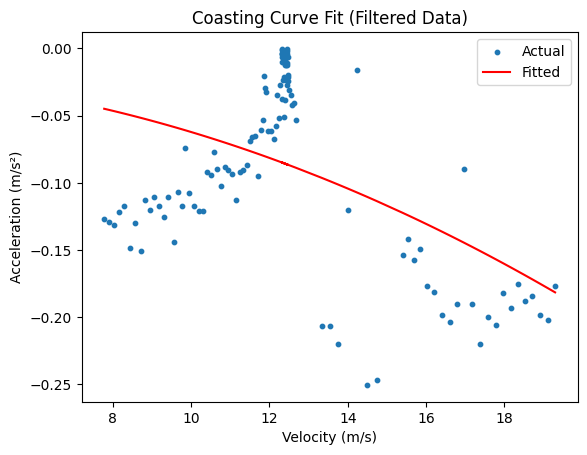

In [1]:
import numpy as np
from numpy.linalg import lstsq
import pandas as pd
import matplotlib.pyplot as plt

# =====================
# LOAD DATA
# =====================
df = pd.read_csv('telemetry_A.csv')
df['timestamp'] = pd.to_datetime(df['timestamp'])

# =====================
# BASIC CLEANING
# =====================
df = df[df['velocity_ms'] > 0]
df = df.dropna()

# =====================
# OUTLIER HANDLING
# =====================

# 1. Remove unrealistic gradients
df = df[np.abs(df['Gradient_deg']) < 2]

# 2. Remove velocity outliers (IQR)
q1 = df['velocity_ms'].quantile(0.25)
q3 = df['velocity_ms'].quantile(0.75)
iqr = q3 - q1

df = df[(df['velocity_ms'] > q1 - 1.5 * iqr) &
        (df['velocity_ms'] < q3 + 1.5 * iqr)]

# =====================
# SMOOTHING
# =====================
df['velocity_ms'] = df['velocity_ms'].rolling(10, center=True).mean()
df = df.dropna()

# =====================
# TIME + VELOCITY
# =====================
t = df['timestamp'].astype('int64') / 1e9
v = df['velocity_ms'].values

# =====================
# ACCELERATION
# =====================
dt = np.diff(t)
dv = np.diff(v)

mask = dt > 0
dt = dt[mask]
dv = dv[mask]
v = v[:-1][mask]

a = dv / dt

# =====================
# REMOVE NON-PHYSICAL DATA
# =====================
# Only consider deceleration (coasting)
mask_phys = a < 0
a = a[mask_phys]
v = v[mask_phys]

# Remove acceleration outliers
a_mean = np.mean(a)
a_std = np.std(a)

mask_a = np.abs(a - a_mean) < 2 * a_std
a = a[mask_a]
v = v[mask_a]

# =====================
# REGRESSION MODEL
# =====================
X = np.column_stack([v**2, np.ones_like(v)])
y = -a

coeffs, _, _, _ = lstsq(X, y, rcond=None)
k1, k2 = coeffs

# =====================
# PARAMETERS
# =====================
rho = 1.225
m = 300
g = 9.81

CdA = (2 * m * k1) / rho
Crr = k2 / g

print(f"CdA: {CdA:.4f} m²")
print(f"Crr: {Crr:.4f}")

# =====================
# VALIDATION CHECK
# =====================
if k1 < 0:
    print("⚠️ Warning: Negative CdA detected — check filtering.")
if k2 < 0:
    print("⚠️ Warning: Negative Crr detected — possible noise influence.")

# =====================
# PLOT
# =====================
a_pred = -(k1 * v**2 + k2)

plt.scatter(v, a, s=10, label="Actual")
plt.plot(v, a_pred, color='red', label="Fitted")
plt.xlabel("Velocity (m/s)")
plt.ylabel("Acceleration (m/s²)")
plt.title("Coasting Curve Fit (Filtered Data)")
plt.legend()
plt.show()

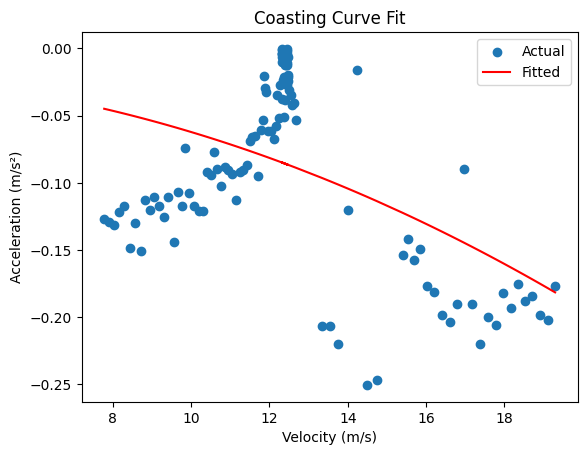

In [3]:
a_pred = -(k1 * v**2 + k2)

plt.scatter(v, a, label="Actual")
plt.plot(v, a_pred, color='red', label="Fitted")
plt.xlabel("Velocity (m/s)")
plt.ylabel("Acceleration (m/s²)")
plt.legend()
plt.title("Coasting Curve Fit")
plt.show()